# E-Commerce Operations & Logistics Performance Analysis

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Objective

This project evaluates the operational performance of an e-commerce business from a management and operations perspective.

The analysis focuses on four areas:

1. **Commercial performance** — sales, order volume, and average order value.
2. **Logistics efficiency** — freight-cost burden and delivery performance.
3. **Customer impact** — the relationship between delivery performance and review scores.
4. **Operational prioritization** — identifying product categories that combine meaningful sales volume with elevated logistics risk.

The final objective is to translate the analysis into **actionable management recommendations**, rather than simply reporting descriptive statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

## 1. Load the Dataset

The project uses the Olist Brazilian e-commerce dataset, which contains interconnected tables covering orders, customers, products, sellers, payments, reviews, and order items.

The files are loaded from the project's `data` directory and stored in a dictionary for convenient access throughout the notebook.

In [2]:
DATA_DIR = Path("../data")

files = list(DATA_DIR.glob("*.csv"))

for file in files:
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


## 2. Load Dataset Tables

Each CSV file is loaded into a dictionary using a simplified table name. This approach keeps the data-loading stage concise while preserving access to each original dataset.

In [3]:
data = {}

for file in files:
    name = file.stem.replace("olist_", "").replace("_dataset", "")
    data[name] = pd.read_csv(file)

for name, df in data.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

customers: 99,441 rows × 5 columns
geolocation: 1,000,163 rows × 5 columns
orders: 99,441 rows × 8 columns
order_items: 112,650 rows × 7 columns
order_payments: 103,886 rows × 5 columns
order_reviews: 99,224 rows × 7 columns
products: 32,951 rows × 9 columns
sellers: 3,095 rows × 4 columns
product_category_name_translation: 71 rows × 2 columns


## 3. Initial Data Structure Review

Before building the analytical dataset, we review the size and structure of each source table.

This step establishes the scope of the available information and helps identify which tables are required for the operational analysis.

In [4]:
for name, df in data.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns)}")
    print("Columns:")
    print(df.columns.tolist())


CUSTOMERS
Rows: 99,441
Columns: 5
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

GEOLOCATION
Rows: 1,000,163
Columns: 5
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

ORDERS
Rows: 99,441
Columns: 8
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER_ITEMS
Rows: 112,650
Columns: 7
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

ORDER_PAYMENTS
Rows: 103,886
Columns: 5
Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

ORDER_REVIEWS
Rows: 99,224
Columns: 7
Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'rev

## 4. Data Quality Assessment

Missing values are assessed across all source tables.

Missing values are not automatically treated as errors: for example, delivery dates may be absent for orders that were not delivered, while review comments may legitimately be blank. The purpose of this step is to understand data completeness before defining the analytical population.

In [5]:
for name, df in data.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n{'=' * 60}")
    print(name.upper())
    print(f"Total rows: {len(df):,}")

    if missing.empty:
        print("No missing values.")
    else:
        print("Missing values:")
        print(missing.sort_values(ascending=False))


CUSTOMERS
Total rows: 99,441
No missing values.

GEOLOCATION
Total rows: 1,000,163
No missing values.

ORDERS
Total rows: 99,441
Missing values:
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

ORDER_ITEMS
Total rows: 112,650
No missing values.

ORDER_PAYMENTS
Total rows: 103,886
No missing values.

ORDER_REVIEWS
Total rows: 99,224
Missing values:
review_comment_title      87656
review_comment_message    58247
dtype: int64

PRODUCTS
Total rows: 32,951
Missing values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS
Total rows: 3,095
No missing values.

PRODUCT_CATEGORY_NAME_TRANSLATION
Total rows: 71
No missing values.


## 5. Duplicate Record Check

Duplicate rows are checked across the source tables. This provides a basic integrity check before the tables are joined.

In [6]:
for name, df in data.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates:,} duplicate rows")

customers: 0 duplicate rows
geolocation: 261,831 duplicate rows
orders: 0 duplicate rows
order_items: 0 duplicate rows
order_payments: 0 duplicate rows
order_reviews: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
product_category_name_translation: 0 duplicate rows


## 6. Explore the Orders Table

The orders table is the central operational table because it contains the order lifecycle, including purchase, approval, carrier delivery, customer delivery, and estimated delivery timestamps.

In [7]:
orders = data["orders"].copy()
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 7. Order Status Distribution

Order status provides an initial view of the operational lifecycle. Delivered orders will later be used as the primary population for realized sales and delivery-performance analysis.

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


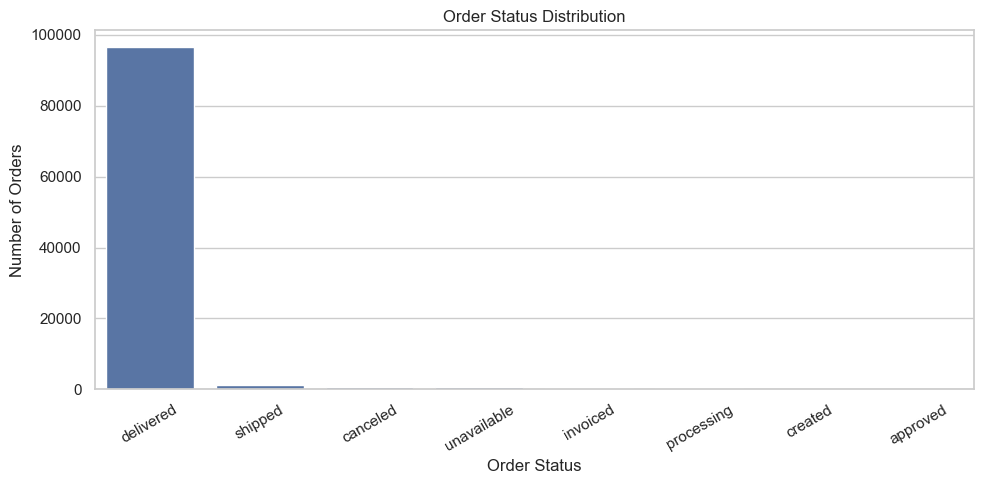

In [8]:
order_status = orders["order_status"].value_counts()

print(order_status)

plt.figure(figsize=(10, 5))
sns.barplot(x=order_status.index, y=order_status.values)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Standardize Order Date Fields

The order lifecycle fields are converted to datetime format so that delivery durations, monthly trends, and other time-based KPIs can be calculated consistently.

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

## 9. Establish Baseline Order KPIs

The first operational KPIs provide a high-level view of order volume and delivery coverage.

These metrics are descriptive and will be refined later using the item-level analytical dataset.

In [10]:
total_orders = orders["order_id"].nunique()

delivered_order_count = orders.loc[
    orders["order_status"] == "delivered",
    "order_id"
].nunique()

delivery_rate = delivered_order_count / total_orders

print(f"Total orders: {total_orders:,}")
print(f"Delivered orders: {delivered_order_count:,}")
print(f"Overall delivery rate: {delivery_rate:.2%}")

Total orders: 99,441
Delivered orders: 96,478
Overall delivery rate: 97.02%


## 10. Define the Analytical Dataset

To evaluate sales, freight, products, and sellers together, the order-items table is enriched with order-level, product-level, seller-level, and category-translation information.

The resulting dataset is at the **order-item level**, which allows sales and freight to be analyzed by category and seller.

In [11]:
order_items = data["order_items"].copy()

orders_subset = orders[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

order_items_analysis = order_items.merge(
    orders_subset,
    on="order_id",
    how="left"
)

products = data["products"].copy()

products_subset = products[
    [
        "product_id",
        "product_category_name",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
].copy()

order_items_analysis = order_items_analysis.merge(
    products_subset,
    on="product_id",
    how="left"
)

sellers = data["sellers"].copy()

order_items_analysis = order_items_analysis.merge(
    sellers,
    on="seller_id",
    how="left"
)

category_translation = data["product_category_name_translation"].copy()

order_items_analysis = order_items_analysis.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

print(f"Analytical dataset: {len(order_items_analysis):,} rows × {len(order_items_analysis.columns)} columns")

Analytical dataset: 112,650 rows × 21 columns


## 11. Create Sales & Logistics Metrics

Two core measures are defined at the item level:

- **Sales value:** product price.
- **Freight cost:** shipping/freight value.

A combined order-item value is also retained for descriptive analysis. These measures form the basis of the commercial and logistics KPIs used later.

In [12]:
order_items_analysis["sales_value"] = order_items_analysis["price"]
order_items_analysis["freight_cost"] = order_items_analysis["freight_value"]

order_items_analysis["total_order_value"] = (
    order_items_analysis["sales_value"]
    + order_items_analysis["freight_cost"]
)

order_items_analysis[
    ["sales_value", "freight_cost", "total_order_value"]
].head()

,sales_value,freight_cost,total_order_value
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


## 12. Validate the Analytical Dataset

The enriched dataset is checked for row count, dimensionality, and missing values after the joins.

This validation helps confirm that the analytical dataset is suitable for downstream KPI calculations.

In [13]:
print(f"Rows: {len(order_items_analysis):,}")
print(f"Columns: {len(order_items_analysis.columns)}")

print("\nLargest sources of missing values:")
print(
    order_items_analysis.isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Rows: 112,650
Columns: 24

Largest sources of missing values:
order_delivered_customer_date    2454
product_category_name_english    1627
product_category_name            1603
product_weight_g                   18
product_length_cm                  18
product_width_cm                   18
product_height_cm                  18
order_id                            0
customer_id                         0
freight_value                       0
price                               0
shipping_limit_date                 0
seller_id                           0
product_id                          0
order_item_id                       0
dtype: int64


## 13. Overall Sales & Operational Performance

This section establishes the project's main commercial KPIs using the complete order-item dataset.

The metrics provide a baseline before focusing specifically on delivered orders and realized performance.

In [14]:
sales_data = order_items_analysis.copy()

total_sales = sales_data["sales_value"].sum()
total_freight = sales_data["freight_cost"].sum()
total_value = sales_data["total_order_value"].sum()

total_orders = sales_data["order_id"].nunique()
total_items = len(sales_data)

average_order_value = total_sales / total_orders

print(f"Total Sales: R$ {total_sales:,.2f}")
print(f"Total Freight Cost: R$ {total_freight:,.2f}")
print(f"Total Sales + Freight: R$ {total_value:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Items Sold: {total_items:,}")
print(f"Average Order Value: R$ {average_order_value:,.2f}")

Total Sales: R$ 13,591,643.70
Total Freight Cost: R$ 2,251,909.54
Total Sales + Freight: R$ 15,843,553.24
Total Orders: 98,666
Total Items Sold: 112,650
Average Order Value: R$ 137.75


## 14. Monthly Sales Trend

Monthly sales and order volume are calculated from purchase dates to identify the overall commercial trajectory.

The analysis period is later restricted to the main period represented in the dataset to avoid interpreting isolated early observations as a meaningful trend.

In [15]:
sales_data["order_month"] = (
    sales_data["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_sales = (
    sales_data
    .groupby("order_month")
    .agg(
        sales=("sales_value", "sum"),
        orders=("order_id", "nunique"),
        freight=("freight_cost", "sum")
    )
    .reset_index()
)

monthly_sales["average_order_value"] = (
    monthly_sales["sales"] / monthly_sales["orders"]
)

monthly_sales["freight_ratio"] = (
    monthly_sales["freight"] / monthly_sales["sales"]
)

monthly_sales.head()

,order_month,sales,orders,freight,average_order_value,freight_ratio
0,2016-09,267.36,3,87.39,89.12,0.33
1,2016-10,"49,507.66",308,"7,301.18",160.74,0.15
2,2016-12,10.90,1,8.72,10.90,0.80
3,2017-01,"120,312.87",789,"16,875.62",152.49,0.14
4,2017-02,"247,303.02",1733,"38,977.60",142.70,0.16


## 15. Sales and Order Volume Visualization

The following charts show the evolution of monthly sales and order volume. Together, they distinguish changes driven by transaction volume from changes in order value.

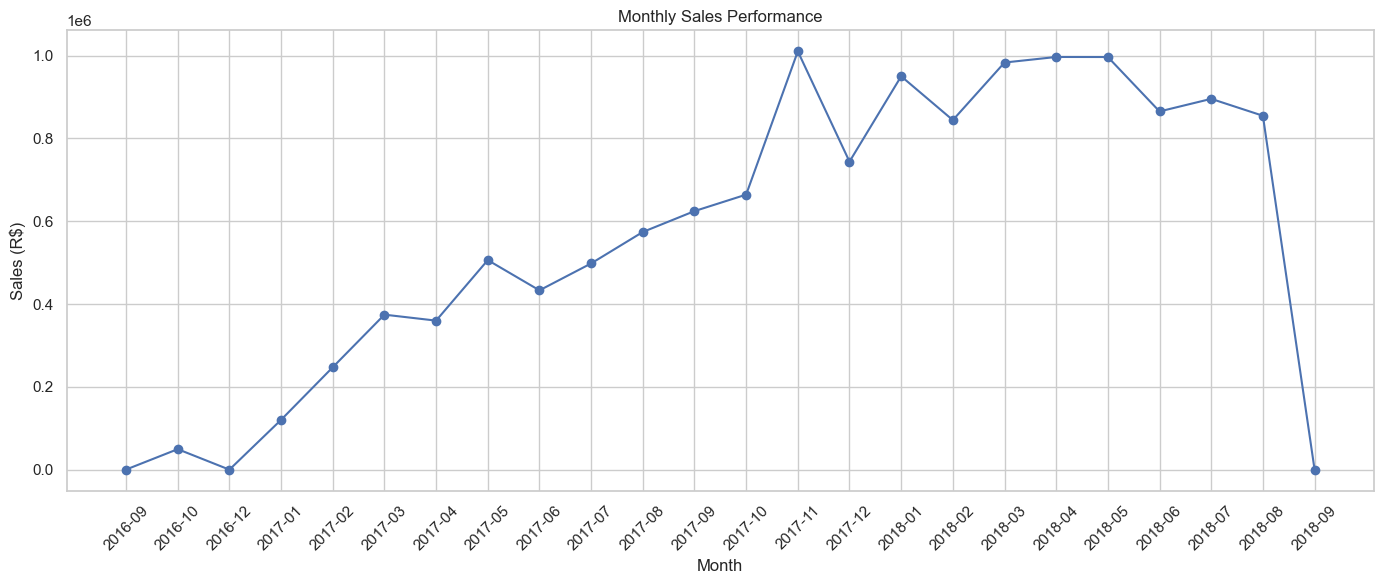

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["sales"],
    marker="o"
)

ax.set_title("Monthly Sales Performance")
ax.set_xlabel("Month")
ax.set_ylabel("Sales (R$)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

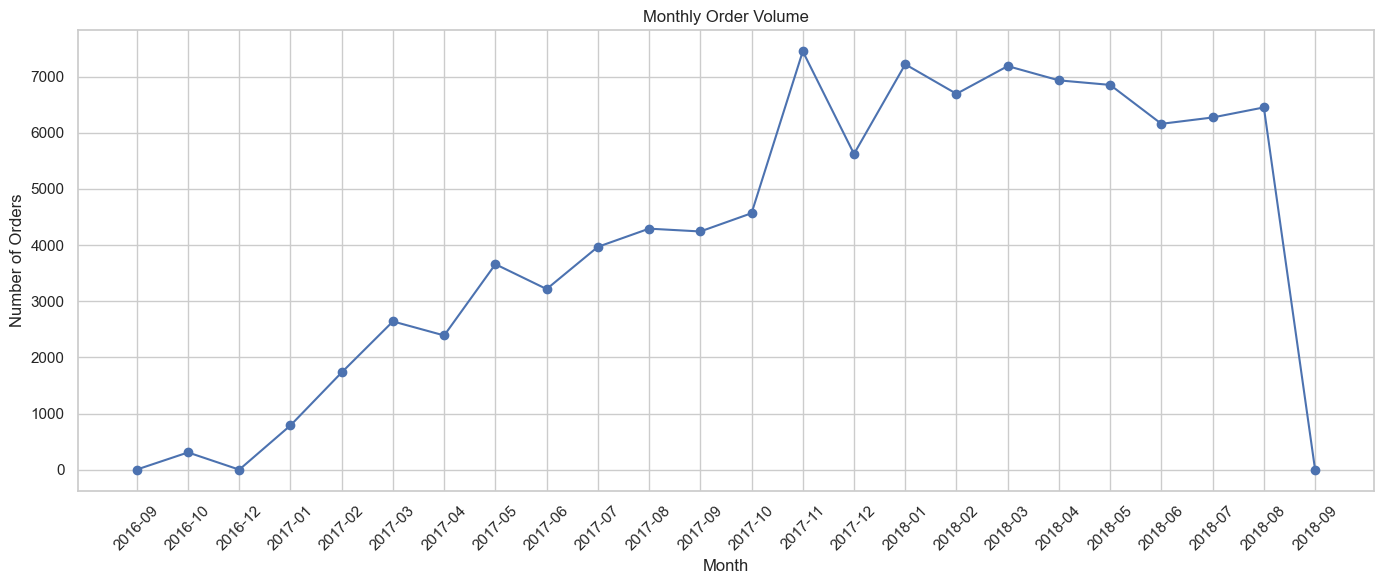

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["orders"],
    marker="o"
)

ax.set_title("Monthly Order Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 16. Freight Cost Burden

Freight cost is evaluated relative to sales because absolute freight spending alone does not indicate whether logistics costs are proportionate to commercial activity.

A high freight-to-sales ratio indicates a greater logistics cost burden.

Freight costs represent 16.57% of total sales.


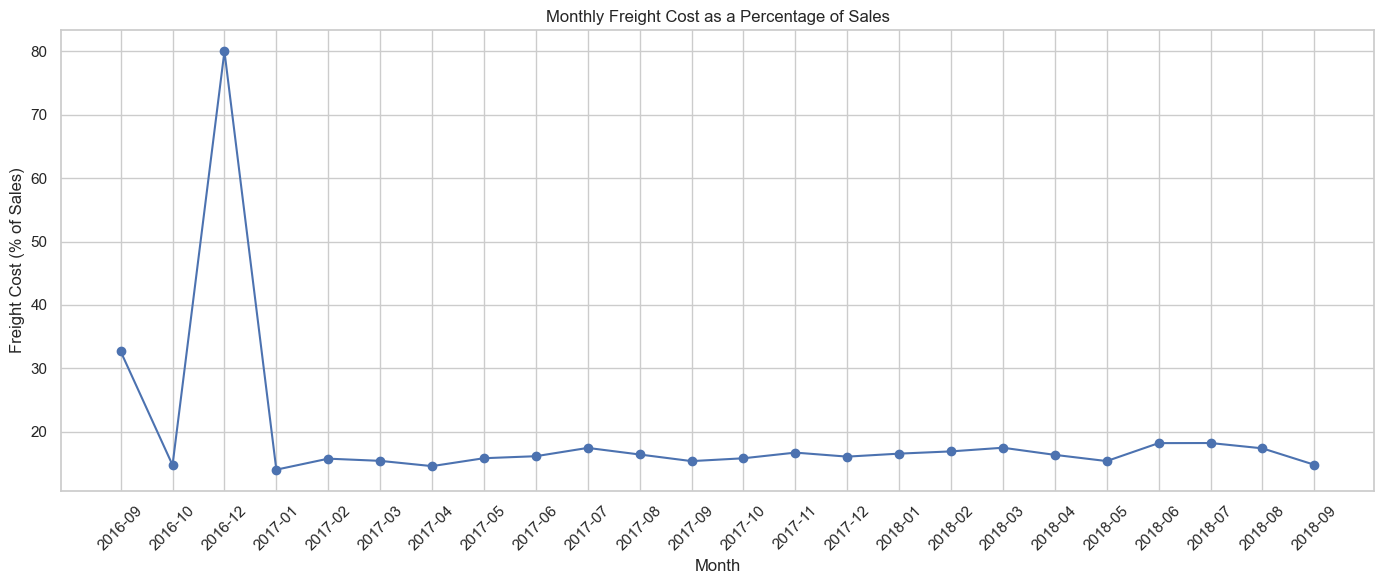

In [18]:
freight_ratio = total_freight / total_sales

print(f"Freight costs represent {freight_ratio:.2%} of total sales.")

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_sales["order_month"],
    monthly_sales["freight_ratio"] * 100,
    marker="o"
)
plt.title("Monthly Freight Cost as a Percentage of Sales")
plt.xlabel("Month")
plt.ylabel("Freight Cost (% of Sales)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Reconcile Orders Across Tables

The order-items table does not necessarily contain every order in the orders table. We quantify this difference and inspect the status of orders without item records.

This is an important data-quality and interpretation check before reporting sales KPIs.

In [19]:
orders_total = orders["order_id"].nunique()
orders_with_items = order_items_analysis["order_id"].nunique()
orders_without_items = orders_total - orders_with_items

print(f"Orders in orders table: {orders_total:,}")
print(f"Orders with item records: {orders_with_items:,}")
print(f"Orders without item records: {orders_without_items:,}")

orders_without_items_df = orders[
    ~orders["order_id"].isin(order_items_analysis["order_id"])
].copy()

print("\nStatus of orders without item records:")
print(orders_without_items_df["order_status"].value_counts())

Orders in orders table: 99,441
Orders with item records: 98,666
Orders without item records: 775

Status of orders without item records:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


## 18. Sales by Order Status

Sales are broken down by order status to distinguish gross transactional activity from sales associated with successfully delivered orders.

This provides the basis for defining **realized sales**.

In [20]:
sales_by_status = (
    sales_data
    .groupby("order_status")
    .agg(
        orders=("order_id", "nunique"),
        items=("order_id", "count"),
        sales=("sales_value", "sum"),
        freight=("freight_cost", "sum")
    )
    .sort_values("sales", ascending=False)
)

sales_by_status

,orders,items,sales,freight
order_status,,,,
delivered,96478,110197,"13,221,498.11","2,198,275.64"
shipped,1106,1185,"150,727.44","26,401.90"
canceled,461,542,"95,235.27","10,650.45"
invoiced,312,359,"61,526.37","7,462.38"
processing,301,357,"60,439.22","8,954.89"
unavailable,6,7,"2,007.69",132.80
approved,2,3,209.60,31.48


## 19. Define Core Realized-Sales KPIs

For management interpretation, delivered orders are treated as the core realized-sales population.

This produces a more operationally meaningful view than using all order statuses indiscriminately.

In [21]:
delivered_data = sales_data[
    sales_data["order_status"] == "delivered"
].copy()

realized_sales = delivered_data["sales_value"].sum()
realized_freight = delivered_data["freight_cost"].sum()
realized_orders = delivered_data["order_id"].nunique()
realized_items = len(delivered_data)

realized_aov = realized_sales / realized_orders
realized_freight_ratio = realized_freight / realized_sales

gross_sales = sales_data["sales_value"].sum()
sales_realization_rate = realized_sales / gross_sales

print(f"Realized Sales: R$ {realized_sales:,.2f}")
print(f"Realized Freight Cost: R$ {realized_freight:,.2f}")
print(f"Delivered Orders: {realized_orders:,}")
print(f"Delivered Items: {realized_items:,}")
print(f"Average Order Value: R$ {realized_aov:,.2f}")
print(f"Freight / Sales Ratio: {realized_freight_ratio:.2%}")
print(f"Sales Realization Rate: {sales_realization_rate:.2%}")

Realized Sales: R$ 13,221,498.11
Realized Freight Cost: R$ 2,198,275.64
Delivered Orders: 96,478
Delivered Items: 110,197
Average Order Value: R$ 137.04
Freight / Sales Ratio: 16.63%
Sales Realization Rate: 97.28%


## 20. Product Category Performance

Delivered sales are aggregated by product category to identify categories that are commercially important and to compare their freight burden.

The analysis uses both sales volume and freight-to-sales ratio rather than relying on sales alone.

In [22]:
category_performance = (
    delivered_data
    .groupby("product_category_name_english", dropna=False)
    .agg(
        sales=("sales_value", "sum"),
        freight=("freight_cost", "sum"),
        items=("order_id", "count"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

category_performance["average_item_price"] = (
    category_performance["sales"]
    / category_performance["items"]
)

category_performance["freight_ratio"] = (
    category_performance["freight"]
    / category_performance["sales"]
)

category_performance = category_performance.sort_values(
    "sales",
    ascending=False
)

category_performance.head(15)

,product_category_name_english,sales,freight,items,orders,average_item_price,freight_ratio
43,health_beauty,"1,233,131.72","178,957.81",9465,8647,130.28,0.15
70,watches_gifts,"1,166,176.98","98,156.14",5859,5495,199.04,0.08
7,bed_bath_table,"1,023,434.76","201,774.50",10953,9272,93.44,0.20
65,sports_leisure,"954,852.55","163,404.36",8431,7530,113.25,0.17
15,computers_accessories,"888,724.61","143,999.16",7644,6530,116.26,0.16
39,furniture_decor,"711,927.69","168,402.23",8160,6307,87.25,0.24
49,housewares,"615,628.69","142,763.56",6795,5743,90.60,0.23
20,cool_stuff,"610,204.10","81,476.79",3718,3559,164.12,0.13
5,auto,"578,966.65","90,488.10",4140,3810,139.85,0.16
69,toys,"471,286.48","75,774.58",4030,3804,116.94,0.16


## 21. Prioritize Categories for Operational Attention

To avoid overreacting to very small categories, only categories with at least 100 delivered items are included in the prioritization framework.

Two objective thresholds are used:

- Median sales among sufficiently large categories.
- Median freight-to-sales ratio among sufficiently large categories.

Categories above both thresholds are classified as **High Priority**.

In [23]:
high_volume_categories = category_performance[
    category_performance["items"] >= 100
].copy()

sales_threshold = high_volume_categories["sales"].median()
freight_threshold = high_volume_categories["freight_ratio"].median()

high_volume_categories["priority"] = np.where(
    (high_volume_categories["sales"] >= sales_threshold) &
    (high_volume_categories["freight_ratio"] >= freight_threshold),
    "High Priority",
    np.where(
        (high_volume_categories["sales"] >= sales_threshold) |
        (high_volume_categories["freight_ratio"] >= freight_threshold),
        "Monitor",
        "Lower Priority"
    )
)

priority_categories = high_volume_categories[
    high_volume_categories["priority"] == "High Priority"
].copy()

priority_categories[
    [
        "product_category_name_english",
        "sales",
        "freight",
        "items",
        "freight_ratio",
        "priority"
    ]
].sort_values("sales", ascending=False)

,product_category_name_english,sales,freight,items,freight_ratio,priority
7,bed_bath_table,"1,023,434.76","201,774.50",10953,0.20,High Priority
39,furniture_decor,"711,927.69","168,402.23",8160,0.24,High Priority
49,housewares,"615,628.69","142,763.56",6795,0.23,High Priority
42,garden_tools,"470,495.28","96,650.40",4268,0.21,High Priority
68,telephony,"309,860.23","69,342.39",4430,0.22,High Priority
57,office_furniture,"268,154.31","67,057.05",1668,0.25,High Priority
66,stationery,"223,788.69","45,786.36",2466,0.20,High Priority
26,electronics,"155,043.93","45,679.16",2729,0.29,High Priority
28,fashion_bags_accessories,"149,329.39","30,558.90",1985,0.20,High Priority
53,luggage_accessories,"138,701.63","30,076.49",1077,0.22,High Priority


## 22. Category Sales vs. Freight Burden

The scatter plot visualizes the trade-off between commercial importance and logistics burden.

The upper-right quadrant represents categories that combine relatively high sales with relatively high freight ratios — the most relevant candidates for operational improvement.

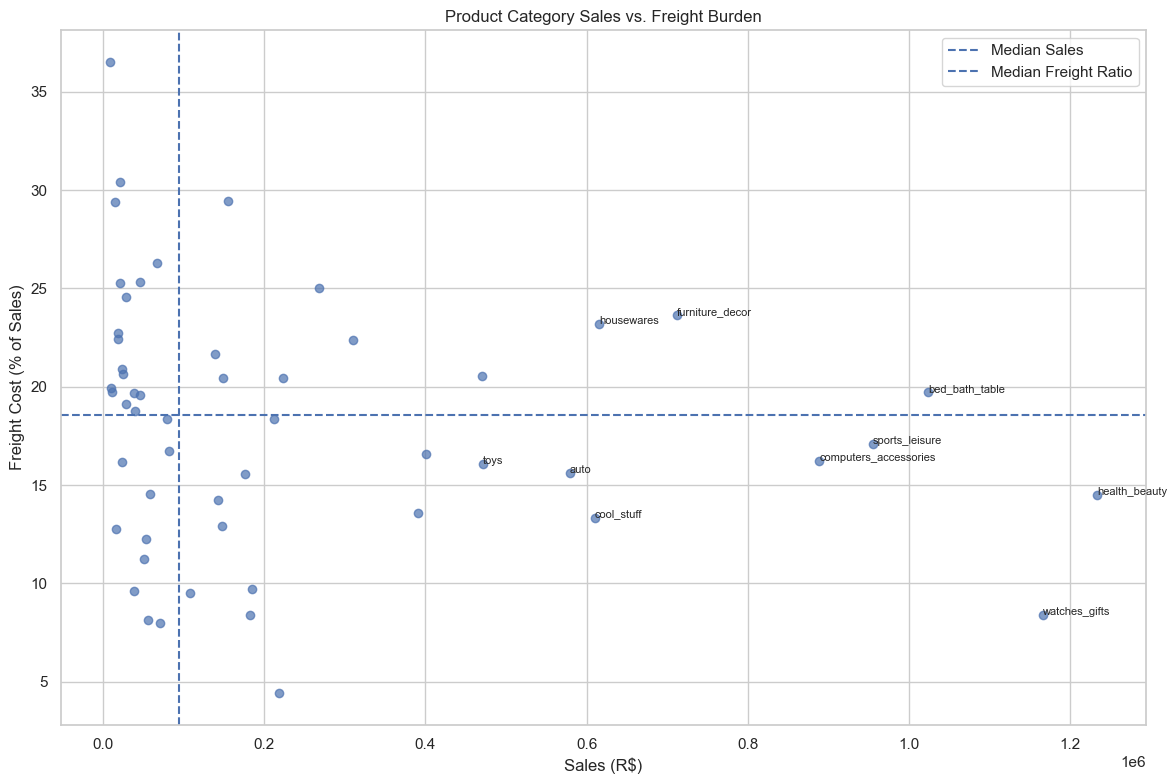

In [24]:
plt.figure(figsize=(12, 8))

plt.scatter(
    high_volume_categories["sales"],
    high_volume_categories["freight_ratio"] * 100,
    alpha=0.7
)

plt.axvline(
    sales_threshold,
    linestyle="--",
    label="Median Sales"
)

plt.axhline(
    freight_threshold * 100,
    linestyle="--",
    label="Median Freight Ratio"
)

for _, row in high_volume_categories.nlargest(10, "sales").iterrows():
    plt.annotate(
        row["product_category_name_english"],
        (row["sales"], row["freight_ratio"] * 100),
        fontsize=8
    )

plt.title("Product Category Sales vs. Freight Burden")
plt.xlabel("Sales (R$)")
plt.ylabel("Freight Cost (% of Sales)")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Quantify the Freight Opportunity

The contribution of high-priority categories is compared with their share of realized sales and realized freight.

A freight share materially above the corresponding sales share indicates that logistics costs are concentrated in categories that generate a smaller proportion of sales than their freight consumption suggests.

In [25]:
priority_sales = priority_categories["sales"].sum()
priority_freight = priority_categories["freight"].sum()

sales_share = priority_sales / realized_sales
freight_share = priority_freight / realized_freight
freight_over_index = freight_share / sales_share

print(f"High-priority category sales: R$ {priority_sales:,.2f}")
print(f"High-priority category freight: R$ {priority_freight:,.2f}")
print(f"Sales share of priority categories: {sales_share:.2%}")
print(f"Freight share of priority categories: {freight_share:.2%}")
print(f"Freight over-index: {freight_over_index:.2f}x")

High-priority category sales: R$ 4,066,364.60
High-priority category freight: R$ 898,091.04
Sales share of priority categories: 30.76%
Freight share of priority categories: 40.85%
Freight over-index: 1.33x


## 24. Order-Level Delivery Dataset

Delivery performance is evaluated at the order level so that each order contributes once to delivery KPIs.

The analysis compares the actual customer delivery date with the estimated delivery date.

In [26]:
delivery_data = (
    sales_data[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ]
    .drop_duplicates("order_id")
    .copy()
)

delivered_orders = delivery_data[
    delivery_data["order_status"] == "delivered"
].copy()

delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

print(f"Unique orders in delivery dataset: {len(delivery_data):,}")

Unique orders in delivery dataset: 98,666


## 25. Delivery Performance

A positive delivery-delay value means the order was delivered after the estimated date.

The key KPIs are:

- **Average delay**
- **Median delay**
- **Late-delivery rate**
- **Number of late orders**

The median is particularly useful because it is less sensitive to extreme delivery delays.

In [27]:
average_delay = delivered_orders["delivery_delay_days"].mean()
median_delay = delivered_orders["delivery_delay_days"].median()

late_orders = delivered_orders[
    delivered_orders["delivery_delay_days"] > 0
]

late_order_rate = len(late_orders) / len(delivered_orders)

print(f"Average delivery delay: {average_delay:.2f} days")
print(f"Median delivery delay: {median_delay:.2f} days")
print(f"Late delivery rate: {late_order_rate:.2%}")
print(f"Late orders: {len(late_orders):,}")

Average delivery delay: -11.18 days
Median delivery delay: -11.95 days
Late delivery rate: 8.11%
Late orders: 7,826


## 26. Delivery Delay Distribution

The distribution shows how actual delivery performance compares with the promised delivery date.

The zero-day reference line represents the estimated delivery date: values above zero indicate late deliveries, while values below zero indicate early deliveries.

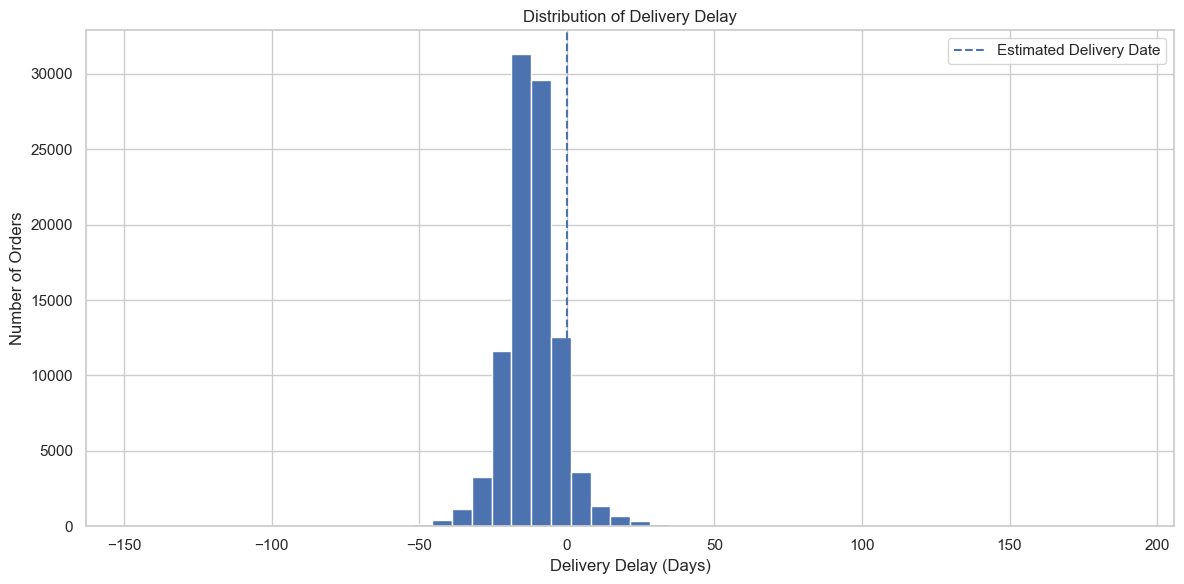

In [28]:
plt.figure(figsize=(12, 6))

plt.hist(
    delivered_orders["delivery_delay_days"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--",
    label="Estimated Delivery Date"
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Orders")
plt.legend()

plt.tight_layout()
plt.show()

## 27. Customer Satisfaction and Delivery Performance

This section evaluates whether late deliveries are associated with lower customer review scores.

The analysis joins delivery performance with order reviews and compares average review scores between:

- **Late deliveries**
- **On-time or early deliveries**

This is an association analysis; it does not establish causality.

In [29]:
# Use the reviews table loaded in the dataset dictionary
order_reviews = data["order_reviews"].copy()

reviews = order_reviews[
    ["order_id", "review_score"]
].drop_duplicates("order_id")

delivery_reviews = delivered_orders[
    ["order_id", "delivery_delay_days"]
].merge(
    reviews,
    on="order_id",
    how="inner"
)

delivery_reviews["delivery_status"] = np.where(
    delivery_reviews["delivery_delay_days"] > 0,
    "Late",
    "On Time / Early"
)

satisfaction_comparison = (
    delivery_reviews
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

satisfaction_comparison

,delivery_status,orders,average_review
0,Late,7661,2.57
1,On Time / Early,88171,4.29


## 28. Quantify Customer Satisfaction Impact

The difference in average review scores provides a concise measure of the customer-experience gap associated with delivery performance.

In [30]:
late_reviews = satisfaction_comparison.loc[
    satisfaction_comparison["delivery_status"] == "Late",
    "average_review"
].iloc[0]

on_time_reviews = satisfaction_comparison.loc[
    satisfaction_comparison["delivery_status"] == "On Time / Early",
    "average_review"
].iloc[0]

review_difference = on_time_reviews - late_reviews

print(f"Average review - Late deliveries: {late_reviews:.2f}/5")
print(f"Average review - On-time/Early deliveries: {on_time_reviews:.2f}/5")
print(f"Customer satisfaction gap: {review_difference:.2f} points")

Average review - Late deliveries: 2.57/5
Average review - On-time/Early deliveries: 4.29/5
Customer satisfaction gap: 1.73 points


## 29. Identify Categories with Higher Delivery Risk

The final analytical step identifies product categories with elevated late-delivery rates.

Only categories with at least 100 delivered items are considered so that very small samples do not dominate the prioritization.

In [31]:
category_delivery = delivered_data[
    ["order_id", "product_category_name_english"]
].merge(
    delivered_orders[
        ["order_id", "delivery_delay_days"]
    ],
    on="order_id",
    how="inner"
)

category_late_rate = (
    category_delivery
    .assign(
        is_late=category_delivery["delivery_delay_days"] > 0
    )
    .groupby("product_category_name_english")
    .agg(
        items=("order_id", "count"),
        late_items=("is_late", "sum"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

category_late_rate["late_rate"] *= 100

category_late_rate = category_late_rate[
    category_late_rate["items"] >= 100
].sort_values(
    "late_rate",
    ascending=False
)

category_late_rate.head(15)

,product_category_name_english,items,late_items,late_rate
4,audio,362,46,12.71
33,fashion_underwear_beach,127,16,12.60
12,christmas_supplies,150,18,12.00
10,books_technical,263,29,11.03
47,home_confort,429,44,10.26
18,construction_tools_lights,301,30,9.97
36,food,499,49,9.82
26,electronics,2729,266,9.75
43,health_beauty,9465,857,9.05
57,office_furniture,1668,149,8.93


## 30. Executive Findings

The analysis identifies four main management findings:

### Commercial performance
- Realized sales are approximately **R$13.22M** across **96,478 delivered orders**.
- Realized average order value is approximately **R$137**.
- The realized freight-to-sales ratio is approximately **16.63%**.

### Logistics cost concentration
- High-priority categories contribute approximately **30.76% of realized sales** but **40.85% of realized freight**.
- Their freight burden therefore over-indexes sales contribution by approximately **1.33×**.

### Delivery performance
- Approximately **8.11% of delivered orders are late**.
- The median delivery is approximately **12 days earlier than the estimated date**, indicating substantial delivery buffers alongside a smaller group of late orders.

### Customer experience
- Late deliveries receive an average review score of approximately **2.57/5**, compared with **4.29/5** for on-time/early deliveries.
- This represents a **1.73-point customer satisfaction gap** associated with delivery performance.

These findings suggest that the most valuable operational opportunity is not simply to reduce total logistics spending, but to **target logistics and delivery improvements where commercial exposure and operational risk overlap**.

## 31. Management Recommendations

### 1. Prioritize high-impact product categories
Focus logistics improvement efforts on categories that combine high sales volume with elevated freight burden. Examples identified in the analysis include categories such as **furniture decor, bed & bath table, housewares, telephony, office furniture, and electronics**.

### 2. Investigate freight-cost drivers
For priority categories, review packaging dimensions, shipment consolidation opportunities, carrier selection, and seller-specific logistics practices.

### 3. Introduce delivery-performance KPIs
A management dashboard should monitor:
- Late-delivery rate
- Freight-to-sales ratio
- Average and median delivery delay
- Sales realization rate
- Customer review score

### 4. Protect customer experience
Because late deliveries are strongly associated with lower review scores, operational teams should use proactive delivery communication and exception management for orders at risk of becoming late.

### 5. Avoid blanket cost reduction
The results support a **targeted optimization strategy** rather than indiscriminate freight reduction. High-volume categories with both financial and service-level exposure should receive priority.

## 32. Conclusion

This project demonstrates how transactional e-commerce data can be translated into management decisions.

Rather than treating sales, logistics, and customer experience as separate problems, the analysis connects them into a single operational framework:

**Sales exposure → Logistics burden → Delivery performance → Customer impact → Management priority**

The resulting recommendations provide a practical starting point for improving logistics efficiency while protecting customer satisfaction.